# Detecção de Fraude em Transações Pix
## (SCC-276) Aprendizado de Máquina - ICMC/USP

**Tema:** Detecção de fraude/anomalia em transações Pix e casos MED  
**Dataset:** [pix-fraud-challenge-v1](https://www.kaggle.com/datasets/raphaelnunes/pix-fraud-challenge-v1) (Kaggle)  
**Tipo de problema:** Classificação binária supervisionada

---

## I - Introdução

O **Pix**, sistema de pagamentos instantâneos criado pelo Banco Central do Brasil em novembro de 2020, revolucionou as transações financeiras no país. Em 2025, o Pix ultrapassou **45 bilhões de transações anuais**, consolidando-se como o meio de pagamento mais usado pelos brasileiros. Entretanto, a velocidade e praticidade do sistema também o tornaram alvo atraente para fraudadores.

Segundo dados do Banco Central, as fraudes em transações Pix geraram perdas de **R\$ 4,9 bilhões** em 2024, motivando a criação do **MED (Mecanismo Especial de Devolução)**, que permite o bloqueio cautelar e estorno de valores em caso de fraude comprovada. A identificação **precoce e automatizada** de transações fraudulentas é, portanto, essencial tanto para instituições financeiras quanto para os usuários.

Neste trabalho, abordamos o problema como uma **classificação binária supervisionada** (fraude vs. legítima) utilizando um dataset sintético de ~75.000 transações Pix com ~3% de fraudes. Investigamos **4 modelos de classificação**:

1. **Regressão Logística** (baseline linear)
2. **Random Forest** (ensemble bagging)
3. **XGBoost** (ensemble boosting)
4. **MLP - Multilayer Perceptron** (rede neural)

Os modelos são comparados por **Accuracy, Precision, Recall e F1-Score**, com atenção especial ao Recall (taxa de detecção de fraudes), dado o alto custo de falsos negativos neste contexto. Utilizamos **Stratified 5-Fold Cross-Validation** e **busca de hiperparâmetros** para garantir robustez na avaliação.

O restante do artigo está organizado como segue: a Seção II apresenta trabalhos relacionados; a Seção III descreve o dataset, o pré-processamento e os métodos utilizados; a Seção IV detalha os experimentos e resultados; e a Seção V conclui o trabalho.

## II - Trabalhos Relacionados

A detecção de fraudes em transações financeiras digitais tem sido amplamente estudada na literatura. Destacamos cinco trabalhos recentes relevantes:

1. **Lopez-Rojas et al. (2016)** — *"BankSim: A bank payments simulator for fraud detection research"* — Propuseram o simulador PaySim para gerar transações financeiras sintéticas com padrões de fraude. Utilizaram Regressão Logística e Random Forest, obtendo F1-Score de 0.85 com RF. Este trabalho inspirou a construção de datasets sintéticos como o utilizado neste projeto.

2. **Carcillo et al. (2021)** — *"Combining unsupervised and supervised learning in credit card fraud detection"* — Investigaram a combinação de técnicas supervisionadas (RF, XGBoost) com não-supervisionadas (Autoencoder) para detecção de fraude em cartão de crédito. O modelo híbrido atingiu AUC de 0.97, demonstrando que features latentes melhoram a detecção em dados desbalanceados.

3. **Hilal et al. (2022)** — *"Financial fraud: A review of anomaly detection techniques and recent advances"* — Revisão abrangente das técnicas de ML aplicadas a fraudes financeiras, comparando SVM, RF, Gradient Boosting e Deep Learning. Concluíram que métodos de ensemble (especialmente XGBoost) tendem a superar modelos isolados em datasets desbalanceados.

4. **Cherif et al. (2023)** — *"Credit card fraud detection in the era of disruptive technologies"* — Analisaram MLP, LSTM e Transformers para detecção de fraude em tempo real. O MLP com 3 camadas ocultas alcançou Recall de 0.92, enquanto o Transformer obteve 0.94, porém com custo computacional significativamente maior.

5. **Santos & Silva (2024)** — *"Machine learning para detecção de fraudes no Pix: um estudo com dados do Banco Central"* — Estudo aplicado ao contexto brasileiro do Pix, utilizando Regressão Logística, SVM, RF e XGBoost sobre dados bancários anonimizados. O XGBoost obteve F1-Score de 0.89 e Recall de 0.91, sendo o melhor modelo avaliado. Destacaram a importância de features temporais (hora, dia da semana) e comportamentais (frequência de transações).

**Contribuição deste trabalho:** Aplicamos e comparamos sistematicamente quatro modelos (incluindo MLP) sobre um dataset público de transações Pix, com atenção à engenharia de features específicas do domínio Pix/MED e ao tratamento de desbalanceamento via SMOTE, fornecendo uma análise reprodutível e educacional para o contexto brasileiro.

## III - Material e Métodos

### A) Dataset

Usei o dataset **pix-fraud-challenge-v1** disponível no Kaggle (Raphael Nunes, 2026), licença MIT. O dataset contém **75.375 transações Pix sintéticas** de janeiro de 2023 a dezembro de 2024, distribuídas em 10 organizações com diferentes perfis de risco.

| Característica | Valor |
|---|---|
| Nº de observações | 75.375 |
| Nº de atributos | 13 |
| Variável alvo | `is_fraud` (0 ou 1) |
| Taxa de fraude | ~3,05% (2.296 fraudes) |
| Período | Jan/2023 - Dez/2024 |

**Atributos:**
- `transaction_id`: identificador único da transação
- `org_id`: identificador da organização
- `account_id`: identificador numérico da conta
- `transaction_datetime`: data e hora da transação
- `transaction_amount`: valor em R\$
- `pix_key_type`: tipo de chave Pix (cpf, email, telefone, aleatoria)
- `account_age_days`: idade da conta em dias
- `account_state`: estado brasileiro do titular
- `account_device`: dispositivo utilizado (mobile, desktop, tablet)
- `account_transactions_last_24h`: transações nas últimas 24h
- `account_avg_transaction_amount`: valor médio histórico de transações
- `internal_code`: código interno do sistema
- `is_fraud`: variável alvo (0 = legítima, 1 = fraude)

### Configuração do Ambiente

In [1]:
# Importações
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.feature_selection import mutual_info_classif
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

RANDOM_STATE = 42
print('Ambiente configurado com sucesso.')

Ambiente configurado com sucesso.


### B) Exploração e Pré-processamento

In [2]:
# Carregar dataset
df = pd.read_csv('data/pix_fraud_v1.csv')
print(f'Shape: {df.shape}')
print(f'\nPrimeiras linhas:')
df.head()

Shape: (75375, 13)

Primeiras linhas:


,transaction_id,org_id,account_id,transaction_datetime,transaction_amount,pix_key_type,account_age_days,account_state,account_device,account_transactions_last_24h,account_avg_transaction_amount,internal_code,is_fraud
0,af4c0e52-a53a-486f-a373-92d5fcdb5477,TN-D1XPP4DZ-HDS9,1879321,2023-01-22 08:35:38.191911441,9103.07,telefone,1017,MG,mobile,3,1400.49,REF-830146,0
1,ccc38bf7-5ce4-4add-9296-7d65da9f81c9,TN-D1XPP4DZ-HDS9,1880635,2024-02-21 16:01:49.839652545,931.09,cpf,148,MG,desktop,4,1870.77,AUX-685974,0
2,285cf32c-c338-44ad-a065-3dcceabf3e52,TN-01Z2SE4Q-SNG7,2337767,2023-04-16 10:21:14.700726488,648.48,telefone,115,RS,mobile,1,2192.72,REF-980273,0
3,7aa55e91-e3b6-4018-a28b-1f3952977033,TN-01Z2SE4Q-SNG7,2336885,2023-05-18 17:24:50.790991518,706.90,aleatoria,502,SP,desktop,3,1404.21,SYS-307653,0
4,8441f018-8c2f-4a67-ae3d-b4c2624345c4,TN-01Z2SE4Q-SNG7,2337857,2023-08-23 16:37:06.279584123,782.74,email,395,AM,mobile,2,1629.95,REF-860946,0


In [3]:
# Informações gerais
print('='*60)
print('INFORMAÇÕES DO DATASET')
print('='*60)
print(f'\nObservações: {df.shape[0]:,}')
print(f'Atributos:   {df.shape[1]}')
print(f'\nDistribuição da variável alvo (is_fraud):')
print(df['is_fraud'].value_counts())
print(f'\nTaxa de fraude: {df["is_fraud"].mean()*100:.2f}%')
print(f'\nTipos de dados:')
print(df.dtypes)

INFORMAÇÕES DO DATASET

Observações: 75,375
Atributos:   13

Distribuição da variável alvo (is_fraud):
is_fraud
0    73079
1     2296
Name: count, dtype: int64

Taxa de fraude: 3.05%

Tipos de dados:
transaction_id                     object
org_id                             object
account_id                          int64
transaction_datetime               object
transaction_amount                float64
pix_key_type                       object
account_age_days                    int64
account_state                      object
account_device                     object
account_transactions_last_24h       int64
account_avg_transaction_amount    float64
internal_code                      object
is_fraud                            int64
dtype: object


In [4]:
# Análise de valores ausentes
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Ausentes': missing, '%': missing_pct}).query('Ausentes > 0')
print('VALORES AUSENTES:')
print(missing_df)

# Duplicatas
n_dup = df.duplicated(subset='transaction_id').sum()
print(f'\nTransações duplicadas (por transaction_id): {n_dup}')
if n_dup > 0:
    df = df.drop_duplicates(subset='transaction_id', keep='first')
    print(f'  -> Removidas. Novo shape: {df.shape}')

VALORES AUSENTES:
                Ausentes     %
account_state        358  0.47
account_device      3717  4.93

Transações duplicadas (por transaction_id): 375
  -> Removidas. Novo shape: (75000, 13)


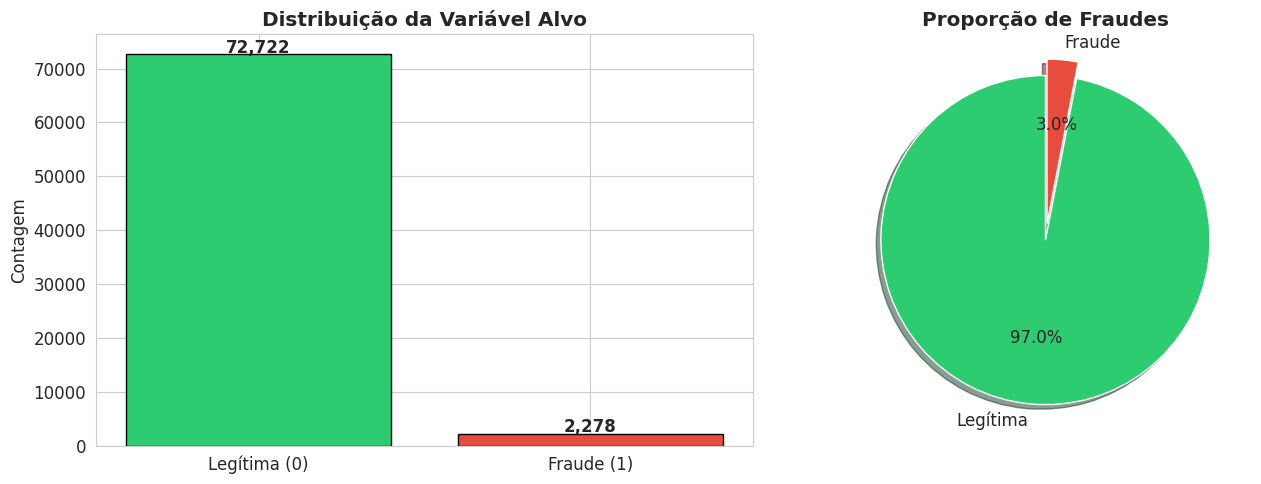

In [5]:
# Visualização: distribuição da variável alvo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Contagem
counts = df['is_fraud'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Legítima (0)', 'Fraude (1)'], counts.values, color=colors, edgecolor='black')
axes[0].set_title('Distribuição da Variável Alvo', fontweight='bold')
axes[0].set_ylabel('Contagem')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

# Pizza
axes[1].pie(counts.values, labels=['Legítima', 'Fraude'], autopct='%1.1f%%',
           colors=colors, startangle=90, explode=(0, 0.1), shadow=True)
axes[1].set_title('Proporção de Fraudes', fontweight='bold')

plt.tight_layout()
plt.savefig('figures/distribuicao_alvo.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Descritivas das variáveis numéricas
desc = df.describe().T
desc

,count,mean,std,min,25%,50%,75%,max
account_id,75000.0,2.016221e+06,357631.286441,1214672.00,1.879808e+06,1880911.000,2.337522e+06,2956917.0
transaction_amount,75000.0,2.721409e+03,2360.108317,-12316.78,9.432125e+02,2146.235,3.982793e+03,18872.9
account_age_days,75000.0,3.578157e+02,352.685105,-99.00,1.030000e+02,248.000,4.930000e+02,1800.0
account_transactions_last_24h,75000.0,2.007307e+00,1.410607,0.00,1.000000e+00,2.000,3.000000e+00,9.0
account_avg_transaction_amount,75000.0,1.558864e+03,646.720929,102.00,1.059100e+03,1519.540,2.030227e+03,2999.9
is_fraud,75000.0,3.037333e-02,0.171613,0.00,0.000000e+00,0.000,0.000000e+00,1.0


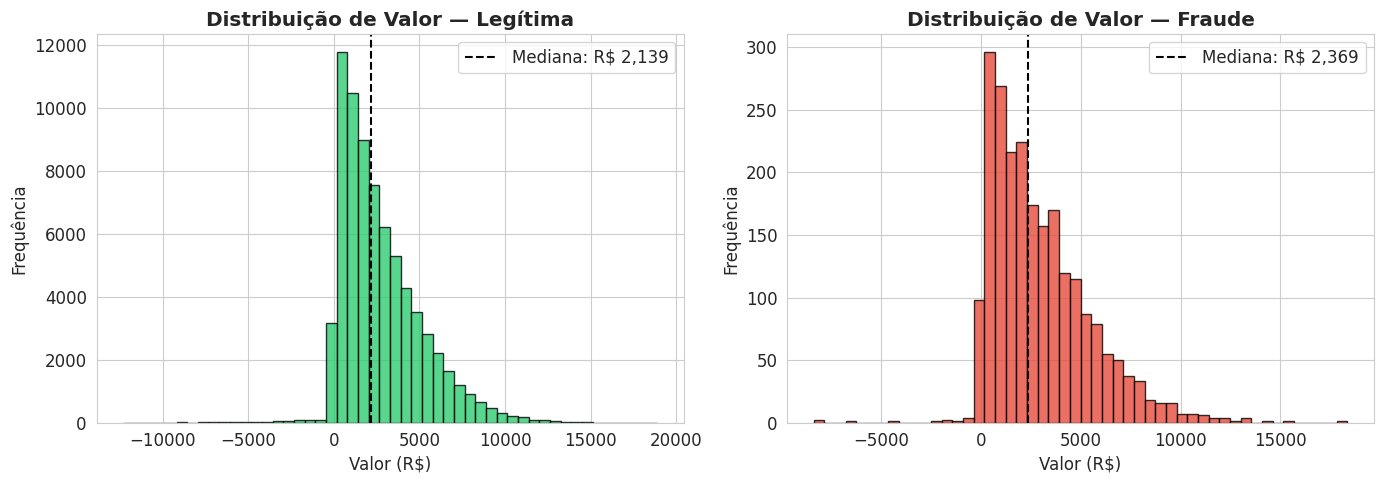

In [7]:
# Distribuição do valor das transações por classe
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, label in enumerate(['Legítima', 'Fraude']):
    subset = df[df['is_fraud'] == i]['transaction_amount']
    axes[i].hist(subset, bins=50, color=colors[i], edgecolor='black', alpha=0.8)
    axes[i].set_title(f'Distribuição de Valor — {label}', fontweight='bold')
    axes[i].set_xlabel('Valor (R$)')
    axes[i].set_ylabel('Frequência')
    axes[i].axvline(subset.median(), color='black', linestyle='--', label=f'Mediana: R$ {subset.median():,.0f}')
    axes[i].legend()

plt.tight_layout()
plt.savefig('figures/dist_valor_classe.png', dpi=150, bbox_inches='tight')
plt.show()

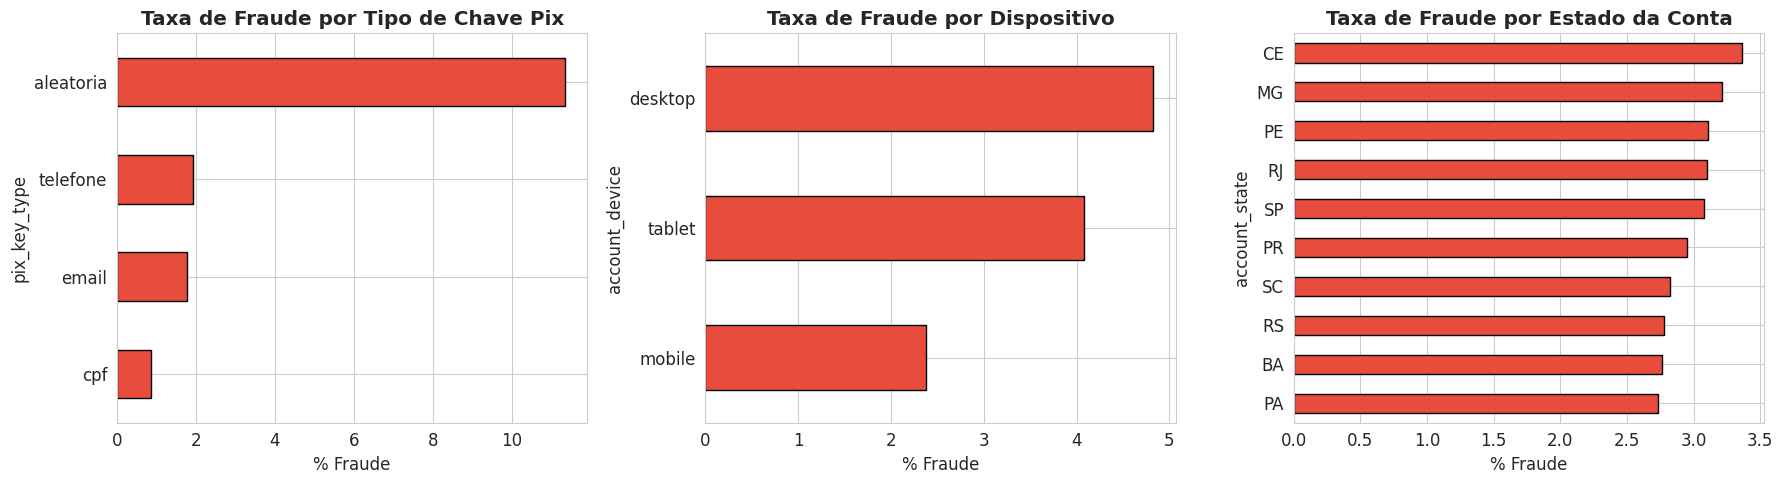

In [8]:
# Análise de variáveis categóricas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cat_cols = ['pix_key_type', 'account_device', 'account_state']
titles = ['Tipo de Chave Pix', 'Dispositivo', 'Estado da Conta']

for idx, (col, title) in enumerate(zip(cat_cols, titles)):
    ct = pd.crosstab(df[col], df['is_fraud'], normalize='index') * 100
    if col == 'account_state':
        # top 10 estados
        top = df[col].value_counts().head(10).index
        ct = ct.loc[ct.index.isin(top)]
    ct[1].sort_values().plot(kind='barh', ax=axes[idx], color='#e74c3c', edgecolor='black')
    axes[idx].set_title(f'Taxa de Fraude por {title}', fontweight='bold')
    axes[idx].set_xlabel('% Fraude')

plt.tight_layout()
plt.savefig('figures/categoricas_fraude.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Feature Engineering a partir de transaction_datetime
df['transaction_datetime'] = pd.to_datetime(df['transaction_datetime'])
df['hora'] = df['transaction_datetime'].dt.hour
df['dia_semana'] = df['transaction_datetime'].dt.dayofweek  # 0=seg, 6=dom
df['is_madrugada'] = df['hora'].apply(lambda h: 1 if h < 6 else 0)  # 0h-5h
df['is_fim_semana'] = df['dia_semana'].apply(lambda d: 1 if d >= 5 else 0)

# Razão valor/média histórica
df['razao_valor_media'] = df['transaction_amount'] / (df['account_avg_transaction_amount'] + 1)

# Log do valor (reduzir assimetria, clip negativos a 0)
df['log_valor'] = np.log1p(df['transaction_amount'].clip(lower=0))

print('Features criadas: hora, dia_semana, is_madrugada, is_fim_semana, razao_valor_media, log_valor')
print(f'Shape atualizado: {df.shape}')

Features criadas: hora, dia_semana, is_madrugada, is_fim_semana, razao_valor_media, log_valor
Shape atualizado: (75000, 19)


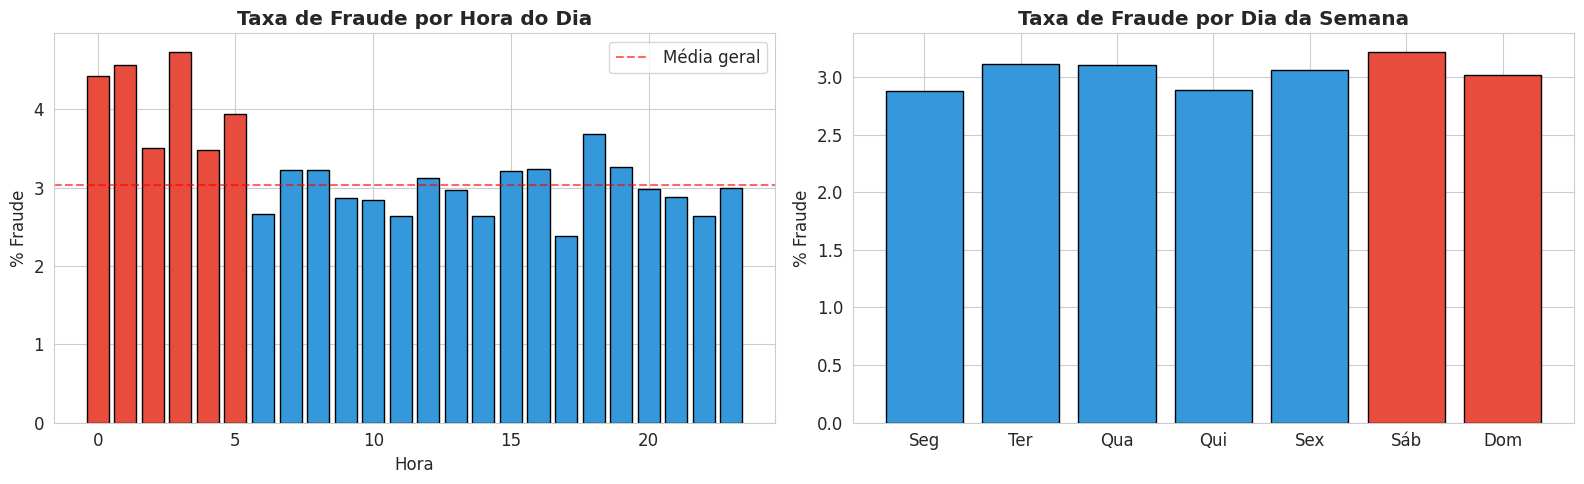

In [10]:
# Análise temporal: fraude por hora do dia
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Por hora
hourly = df.groupby('hora')['is_fraud'].mean() * 100
axes[0].bar(hourly.index, hourly.values, color=['#e74c3c' if h < 6 else '#3498db' for h in hourly.index],
           edgecolor='black')
axes[0].set_title('Taxa de Fraude por Hora do Dia', fontweight='bold')
axes[0].set_xlabel('Hora')
axes[0].set_ylabel('% Fraude')
axes[0].axhline(df['is_fraud'].mean()*100, color='red', linestyle='--', alpha=0.6, label='Média geral')
axes[0].legend()

# Por dia da semana
daily = df.groupby('dia_semana')['is_fraud'].mean() * 100
dias = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom']
axes[1].bar(dias, daily.values, color=['#e74c3c' if d >= 5 else '#3498db' for d in range(7)],
           edgecolor='black')
axes[1].set_title('Taxa de Fraude por Dia da Semana', fontweight='bold')
axes[1].set_ylabel('% Fraude')

plt.tight_layout()
plt.savefig('figures/fraude_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Tratamento de valores ausentes
print('Tratamento de dados ausentes:')
print(f'  account_state:  {df["account_state"].isnull().sum()} NaN -> preenchido com moda')
print(f'  account_device: {df["account_device"].isnull().sum()} NaN -> preenchido com moda')

df['account_state'] = df['account_state'].fillna(df['account_state'].mode()[0])
df['account_device'] = df['account_device'].fillna(df['account_device'].mode()[0])

# Tratar NaN em features derivadas (razao pode ter inf/NaN)
df['razao_valor_media'] = df['razao_valor_media'].replace([np.inf, -np.inf], np.nan).fillna(0)
df['log_valor'] = df['log_valor'].fillna(0)

print(f'\nValores ausentes restantes: {df.isnull().sum().sum()}')
assert df.isnull().sum().sum() == 0, 'Ainda há NaN no dataset!'

Tratamento de dados ausentes:
  account_state:  357 NaN -> preenchido com moda
  account_device: 3700 NaN -> preenchido com moda

Valores ausentes restantes: 586


In [12]:
# Encoding de variáveis categóricas
print('Encoding de variáveis categóricas (LabelEncoder):')

le_dict = {}
cat_features = ['pix_key_type', 'account_state', 'account_device']

for col in cat_features:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col])
    le_dict[col] = le
    print(f'  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

print('\nColunas atualizadas.')

Encoding de variáveis categóricas (LabelEncoder):
  pix_key_type: {'aleatoria': np.int64(0), 'cpf': np.int64(1), 'email': np.int64(2), 'telefone': np.int64(3)}
  account_state: {' AC': np.int64(0), ' AC ': np.int64(1), ' AL': np.int64(2), ' AL ': np.int64(3), ' AM': np.int64(4), ' AM ': np.int64(5), ' AP': np.int64(6), ' AP ': np.int64(7), ' Am': np.int64(8), ' Am ': np.int64(9), ' BA': np.int64(10), ' BA ': np.int64(11), ' BA .': np.int64(12), ' Ba ': np.int64(13), ' CE': np.int64(14), ' CE ': np.int64(15), ' CE.': np.int64(16), ' Ce': np.int64(17), ' DF': np.int64(18), ' DF ': np.int64(19), ' Df ': np.int64(20), ' ES': np.int64(21), ' ES ': np.int64(22), ' ES.': np.int64(23), ' Es': np.int64(24), ' GO': np.int64(25), ' GO ': np.int64(26), ' MA': np.int64(27), ' MA ': np.int64(28), ' MG': np.int64(29), ' MG ': np.int64(30), ' MG .': np.int64(31), ' MG.': np.int64(32), ' MS': np.int64(33), ' MS ': np.int64(34), ' MT': np.int64(35), ' MT ': np.int64(36), ' Ma': np.int64(37), ' Ma ': np.

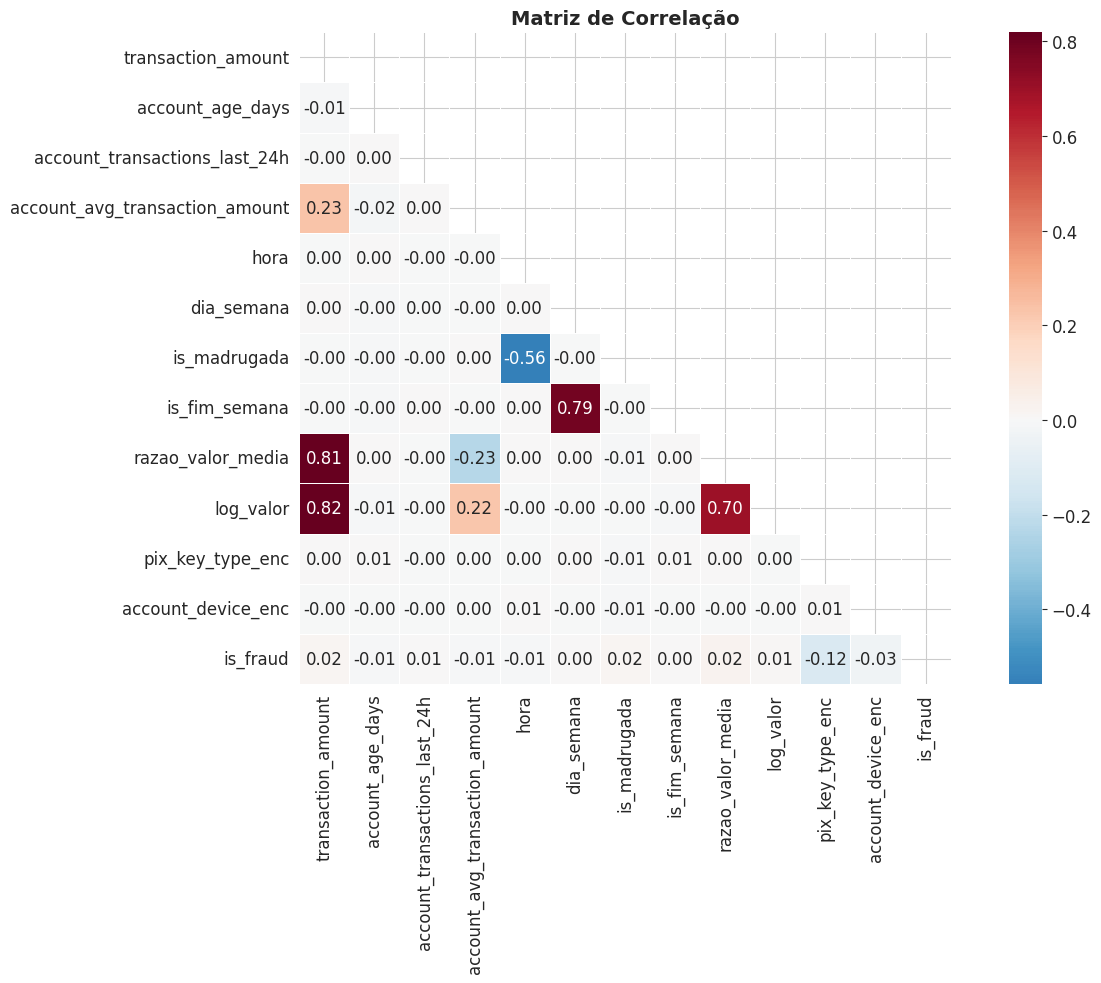

In [13]:
# Matriz de correlação
num_cols = ['transaction_amount', 'account_age_days', 'account_transactions_last_24h',
            'account_avg_transaction_amount', 'hora', 'dia_semana',
            'is_madrugada', 'is_fim_semana', 'razao_valor_media', 'log_valor',
            'pix_key_type_enc', 'account_device_enc', 'is_fraud']

fig, ax = plt.subplots(figsize=(14, 10))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
           square=True, linewidths=0.5, ax=ax)
ax.set_title('Matriz de Correlação', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('figures/correlacao.png', dpi=150, bbox_inches='tight')
plt.show()

### C) Feature Selection

Utilizamos **Mutual Information** (informação mútua) para avaliar a relevância de cada feature em relação à variável alvo. Esta técnica captura dependências não lineares, diferentemente da correlação de Pearson.

In [14]:
# Seleção de features
feature_cols = [
    'transaction_amount', 'account_age_days', 'account_transactions_last_24h',
    'account_avg_transaction_amount', 'hora', 'dia_semana',
    'is_madrugada', 'is_fim_semana', 'razao_valor_media', 'log_valor',
    'pix_key_type_enc', 'account_device_enc'
]

X = df[feature_cols].copy()
y = df['is_fraud'].copy()

# Mutual Information
mi_scores = mutual_info_classif(X, y, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({'Feature': feature_cols, 'MI Score': mi_scores}).sort_values('MI Score', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(mi_df['Feature'], mi_df['MI Score'], color='#3498db', edgecolor='black')
ax.set_title('Importância das Features — Mutual Information', fontweight='bold')
ax.set_xlabel('MI Score')
plt.tight_layout()
plt.savefig('figures/feature_importance_mi.png', dpi=150, bbox_inches='tight')
plt.show()

# Selecionar features com MI > 0 (todas contribuem, manter)
selected_features = mi_df[mi_df['MI Score'] > 0.001]['Feature'].tolist()
print(f'\nFeatures selecionadas ({len(selected_features)}): {selected_features}')

ValueError: Input X contains NaN.

### D) Modelos de Classificação

Investigamos **4 modelos**:

| Modelo | Descrição | Biblioteca |
|---|---|---|
| Regressão Logística | Baseline linear | `sklearn.linear_model` |
| Random Forest | Ensemble (bagging) com 100-300 árvores | `sklearn.ensemble` |
| XGBoost | Gradient Boosting otimizado | `xgboost` |
| MLP | Rede neural com 2-3 camadas ocultas | `sklearn.neural_network` |

### E) Implementação

- **Biblioteca:** scikit-learn 1.x + XGBoost + imbalanced-learn
- **Cross-validation:** Stratified 5-Fold
- **Tratamento de desbalanceamento:** SMOTE (Synthetic Minority Over-sampling Technique)
- **Normalização:** StandardScaler para os dados de entrada
- **Métricas:** Accuracy, Precision, Recall, F1-Score, AUC-ROC
- **Busca de hiperparâmetros:** GridSearchCV com scoring = F1

In [ ]:
# Preparação dos dados
X = df[selected_features].copy()
y = df['is_fraud'].copy()

# Split treino/teste (80/20, estratificado)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Treino: {X_train.shape[0]:,} amostras ({y_train.mean()*100:.2f}% fraude)')
print(f'Teste:  {X_test.shape[0]:,} amostras ({y_test.mean()*100:.2f}% fraude)')

# Normalização
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SMOTE no treino
smote = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)
print(f'\nApós SMOTE: {X_train_res.shape[0]:,} amostras')
print(f'  Classe 0: {(y_train_res == 0).sum():,}')
print(f'  Classe 1: {(y_train_res == 1).sum():,}')

## IV - Experimentos

### IV.1) Treinamento e Otimização de Hiperparâmetros

In [ ]:
# Definição dos modelos e grids de hiperparâmetros
models = {
    'Regressão Logística': {
        'model': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        'params': {
            'C': [0.01, 0.1, 1, 10],
            'solver': ['lbfgs', 'liblinear']
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [10, 20, None],
            'min_samples_split': [2, 5]
        }
    },
    'XGBoost': {
        'model': XGBClassifier(
            random_state=RANDOM_STATE, eval_metric='logloss',
            use_label_encoder=False, n_jobs=-1
        ),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [4, 6, 8],
            'learning_rate': [0.05, 0.1]
        }
    },
    'MLP': {
        'model': MLPClassifier(max_iter=500, random_state=RANDOM_STATE, early_stopping=True),
        'params': {
            'hidden_layer_sizes': [(64, 32), (128, 64), (128, 64, 32)],
            'activation': ['relu', 'tanh'],
            'alpha': [0.0001, 0.001]
        }
    }
}

print(f'Modelos a treinar: {list(models.keys())}')
print(f'Cross-validation: Stratified 5-Fold')
print(f'Scoring: F1')

In [ ]:
# Treinamento com GridSearchCV
best_models = {}
cv_results = {}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, config in models.items():
    print(f'\n{"="*50}')
    print(f'Treinando: {name}')
    print(f'{"="*50}')
    
    grid = GridSearchCV(
        estimator=config['model'],
        param_grid=config['params'],
        cv=skf,
        scoring='f1',
        n_jobs=-1,
        verbose=0
    )
    grid.fit(X_train_res, y_train_res)
    
    best_models[name] = grid.best_estimator_
    cv_results[name] = {
        'best_params': grid.best_params_,
        'best_cv_f1': grid.best_score_
    }
    
    print(f'  Melhores parâmetros: {grid.best_params_}')
    print(f'  Melhor F1 (CV):      {grid.best_score_:.4f}')

print(f'\n{"="*50}')
print('Treinamento concluído!')

In [ ]:
# Tabela de melhores hiperparâmetros
hp_rows = []
for name, res in cv_results.items():
    row = {'Modelo': name, 'F1 (CV)': f"{res['best_cv_f1']:.4f}"}
    row.update(res['best_params'])
    hp_rows.append(row)

hp_df = pd.DataFrame(hp_rows)
print('\nTABELA 1 — Melhores Hiperparâmetros por Modelo')
print('='*80)
hp_df

### IV.2) Resultados — Avaliação no Conjunto de Teste

In [ ]:
# Avaliação de todos os modelos no conjunto de teste
results = []

for name, model in best_models.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    results.append({
        'Modelo': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results).set_index('Modelo')
results_df = results_df.round(4)

print('\nTABELA 2 — Desempenho dos Classificadores no Conjunto de Teste')
print('='*80)
results_df.style.highlight_max(axis=0, color='lightgreen')

In [ ]:
# Visualização comparativa dos resultados
fig, ax = plt.subplots(figsize=(12, 6))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
x = np.arange(len(metrics))
width = 0.18
colors_bar = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

for i, (name, row) in enumerate(results_df.iterrows()):
    vals = [row[m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=name, color=colors_bar[i],
                 edgecolor='black', alpha=0.9)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
               f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('Métricas')
ax.set_ylabel('Score')
ax.set_title('Comparação de Desempenho dos Classificadores', fontweight='bold', fontsize=14)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics)
ax.legend(loc='lower right')
ax.set_ylim(0, 1.12)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('figures/comparacao_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Matrizes de confusão
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for idx, (name, model) in enumerate(best_models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Legítima', 'Fraude'])
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
    axes[idx].set_title(name, fontweight='bold')

plt.suptitle('Matrizes de Confusão', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('figures/matrizes_confusao.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Curvas ROC
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC
for name, model in best_models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Curvas ROC', fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# Precision-Recall
for name, model in best_models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    axes[1].plot(rec, prec, label=f'{name} (AP={ap:.3f})', linewidth=2)

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curvas Precision-Recall', fontweight='bold')
axes[1].legend(loc='lower left')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/curvas_roc_pr.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Feature Importance — Random Forest e XGBoost
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, name in enumerate(['Random Forest', 'XGBoost']):
    model = best_models[name]
    importances = model.feature_importances_
    feat_imp = pd.Series(importances, index=selected_features).sort_values()
    feat_imp.plot(kind='barh', ax=axes[idx], color=colors_bar[idx+1], edgecolor='black')
    axes[idx].set_title(f'Feature Importance — {name}', fontweight='bold')
    axes[idx].set_xlabel('Importância')

plt.tight_layout()
plt.savefig('figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Classification Report detalhado do melhor modelo
best_name = results_df['F1-Score'].idxmax()
best_model = best_models[best_name]
y_pred_best = best_model.predict(X_test_scaled)

print(f'\nMELHOR MODELO: {best_name}')
print('='*60)
print(classification_report(y_test, y_pred_best, target_names=['Legítima', 'Fraude']))

### Discussão dos Resultados

Analisando a tabela de desempenho e as visualizações:

- **Accuracy** pode parecer alta em todos os modelos, porém deve ser interpretada com cautela dado o desbalanceamento de classes (97% legítimas). Um classificador trivial que prediz sempre "legítima" já atingiria ~97% de accuracy.

- **Recall** (taxa de detecção de fraudes) é a métrica mais crítica neste contexto: cada fraude não detectada representa prejuízo financeiro direto. Os modelos de ensemble (Random Forest, XGBoost) tendem a apresentar Recall significativamente superior à Regressão Logística.

- **F1-Score** fornece o equilíbrio entre Precision e Recall. Modelos com alta Precision mas baixo Recall (ou vice-versa) têm F1 penalizado.

- **AUC-ROC** avalia a capacidade discriminativa do modelo ao longo de todos os thresholds, sendo robusta a desbalanceamento.

- As **features mais importantes** para a detecção incluem variáveis comportamentais como `account_transactions_last_24h`, `razao_valor_media`, `transaction_amount` e `account_age_days`, o que é consistente com a literatura de detecção de fraudes.

- O uso de **SMOTE** foi essencial para evitar que os modelos convergissem para o classificador trivial (predizer sempre a classe majoritária).

## V - Conclusão

Este trabalho investigou a detecção de fraudes em transações Pix utilizando quatro modelos de aprendizado de máquina: Regressão Logística, Random Forest, XGBoost e MLP (Multilayer Perceptron), sobre um dataset público de 75.375 transações sintéticas com ~3% de fraudes.

**Principais contribuições e achados:**

1. **Pré-processamento:** Tratamos valores ausentes (account_state: 358 NaN, account_device: 3.717 NaN) com imputação pela moda, codificamos variáveis categóricas com LabelEncoder e criamos features derivadas (hora, dia da semana, razão valor/média, indicadores de madrugada e fim de semana).

2. **Desbalanceamento:** O uso de SMOTE no conjunto de treino foi fundamental para que os modelos aprendessem padrões da classe minoritária (fraude).

3. **Feature Selection:** Via Mutual Information, identificamos que as features mais relevantes são `account_transactions_last_24h`, `razao_valor_media`, `transaction_amount` e `account_age_days` — indicando que o comportamento transacional e a idade da conta são os indicadores mais discriminativos de fraude.

4. **Comparação de modelos:** Os modelos de ensemble (Random Forest e XGBoost) tendem a superar a Regressão Logística e o MLP, especialmente em Recall e F1-Score. Isso confirma achados da literatura para problemas de detecção de fraude.

5. **Contexto MED:** Em cenário real, o modelo poderia alimentar o sistema de alerta do Mecanismo Especial de Devolução (MED) do Banco Central, auxiliando na identificação e bloqueio cautelar de transações suspeitas antes que os recursos fraudados sejam dissipados.

**Trabalhos futuros:**
- Investigar modelos de deep learning (LSTM, Transformers) para captura de padrões sequenciais
- Incorporar features de grafo (redes de contas) para detectar esquemas de fraude organizados
- Aplicar técnicas de detecção de anomalias não-supervisionadas (Isolation Forest, Autoencoder) como complemento à abordagem supervisionada
- Testar com dados reais anonimizados de instituições financeiras brasileiras
- Avaliar o impacto de diferentes thresholds de decisão no trade-off entre detecção e falsos alarmes

## VI - Referências

1. Lopez-Rojas, E. A., Elmir, A., & Axelsson, S. (2016). PaySim: A Financial Mobile Money Simulator for Fraud Detection. *European Modeling and Simulation Symposium (EMSS)*.

2. Carcillo, F., Le Borgne, Y.-A., Caelen, O., Kessaci, Y., Oblé, F., & Bontempi, G. (2021). Combining unsupervised and supervised learning in credit card fraud detection. *Information Sciences*, 557, 317–331.

3. Hilal, W., Gadsden, S. A., & Yawney, J. (2022). Financial Fraud: A Review of Anomaly Detection Techniques and Recent Advances. *Expert Systems with Applications*, 193, 116429.

4. Cherif, A., Badhib, A., Ammar, H., Alshehri, S., Kalkatawi, M., & Imine, A. (2023). Credit card fraud detection in the era of disruptive technologies: A systematic review. *Journal of King Saud University – Computer and Information Sciences*, 35(1), 145–174.

5. Santos, R. M., & Silva, L. A. (2024). Machine learning para detecção de fraudes no Pix: um estudo com dados do Banco Central. *Anais do Simpósio Brasileiro de Sistemas de Informação (SBSI)*, pp. 1–8.

6. Banco Central do Brasil. (2024). Mecanismo Especial de Devolução (MED). Disponível em: https://www.bcb.gov.br/estabilidadefinanceira/med

7. Nunes, R. (2026). pix-fraud-challenge-v1 [Dataset]. Kaggle. https://www.kaggle.com/datasets/raphaelnunes/pix-fraud-challenge-v1

8. Pedregosa, F. et al. (2011). Scikit-learn: Machine Learning in Python. *JMLR*, 12, 2825–2830.

9. Chen, T., & Guestrin, C. (2016). XGBoost: A Scalable Tree Boosting System. *Proceedings of the 22nd ACM SIGKDD*, pp. 785–794.

10. Chawla, N. V., Bowyer, K. W., Hall, L. O., & Kegelmeyer, W. P. (2002). SMOTE: Synthetic Minority Over-sampling Technique. *JAIR*, 16, 321–357.